# Currency Momentum Strategy

This notebook implements a currency strength momentum strategy that rotates between major G10 currencies. Unlike traditional stock/bond dual momentum, this strategy measures relative momentum across currencies and constructs pairs by going long the strongest currencies against the weakest.

**Why This Makes Sense for FX:**
- Currency markets are zero-sum (being long one currency means being short another)
- No equivalent of "cash" position - you're always in some currency
- Momentum effects exist in FX but manifest as relative strength between currencies
- By ranking currencies and creating pairs, we capture momentum while maintaining market exposure

**Currency Universe:**
- EUR (Euro), GBP (British Pound), JPY (Japanese Yen)
- CHF (Swiss Franc), AUD (Australian Dollar)
- CAD (Canadian Dollar), NZD (New Zealand Dollar)

**Requirements:**
```bash
pip install yfinance pandas numpy matplotlib
```

## Import Required Libraries


In [1]:
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from typing import Dict, List
%matplotlib inline


## Configure Display Options


In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)
pd.options.display.float_format = '{:.4f}'.format


## Strategy Parameters

Configure the backtest parameters. The strategy will:
1. Calculate momentum for each currency (rate of change over lookback period)
2. Rank currencies by momentum
3. Go long the top N currencies
4. Go short the bottom N currencies
5. Rebalance periodically


In [3]:
# Backtest period
start_date = '2010-01-01'
end_date = datetime.date.today()

# Strategy parameters
momentum_lookback = 60  # Days to calculate momentum (roughly 3 months)
rebalance_frequency = 20  # Rebalance every 20 days (roughly monthly)
top_n = 2  # Number of currencies to go long
bottom_n = 2  # Number of currencies to go short

# Currency pairs to track (vs USD)
# Format: 'CURRENCY=X' for Yahoo Finance
currencies = {
    'EUR': 'EURUSD=X',
    'GBP': 'GBPUSD=X',
    'JPY': 'JPYUSD=X',
    'CHF': 'CHFUSD=X',
    'AUD': 'AUDUSD=X',
    'CAD': 'CADUSD=X',
    'NZD': 'NZDUSD=X'
}

print(f"Tracking {len(currencies)} currencies")
print(f"Momentum lookback: {momentum_lookback} days")
print(f"Rebalancing every {rebalance_frequency} days")
print(f"Long {top_n} strongest, Short {bottom_n} weakest")


Tracking 7 currencies
Momentum lookback: 60 days
Rebalancing every 20 days
Long 2 strongest, Short 2 weakest


## Download Currency Data

Fetch historical exchange rates from Yahoo Finance. All rates are quoted vs USD.


In [4]:
def download_fx_data(currencies: Dict[str, str], start: str, end: datetime.date) -> pd.DataFrame:
    """
    Download FX data from Yahoo Finance
    """
    print(f"Downloading data for {len(currencies)} currency pairs...")
    
    tickers = list(currencies.values())
    data = yf.download(tickers, start=start, end=end, progress=False, auto_adjust=False)
    
    # Extract close prices
    if len(tickers) > 1:
        prices = data['Close']
    else:
        prices = data[['Close']]
    
    # Rename columns to currency codes
    ticker_to_currency = {v: k for k, v in currencies.items()}
    prices.columns = [ticker_to_currency.get(col, col) for col in prices.columns]
    
    # Drop NaN values
    prices = prices.dropna()
    
    print(f"Downloaded {len(prices)} days of data")
    print(f"Date range: {prices.index[0].strftime('%Y-%m-%d')} to {prices.index[-1].strftime('%Y-%m-%d')}")
    
    return prices

# Download the data
fx_prices = download_fx_data(currencies, start_date, end_date)
fx_prices.head()


Downloaded 4110 days of data
Date range: 2010-01-01 to 2025-10-17


,AUD,CAD,CHF,EUR,GBP,JPY,NZD
Date,,,,,,,
2010-01-01,0.8985,0.9513,0.9672,1.4390,1.6133,0.0108,0.7245
2010-01-04,0.9125,0.9606,0.9717,1.4424,1.6114,0.0108,0.7342
2010-01-05,0.9118,0.9620,0.9674,1.4366,1.5991,0.0109,0.7338
2010-01-06,0.9205,0.9691,0.9731,1.4404,1.6024,0.0108,0.7380
2010-01-07,0.9178,0.9671,0.9675,1.4318,1.5934,0.0107,0.7327


## Calculate Currency Momentum

Momentum is measured as the rate of change over the lookback period. A positive momentum means the currency has strengthened against USD.


In [5]:
# Calculate momentum (rate of change)
fx_momentum = fx_prices.pct_change(momentum_lookback)

print("Sample momentum values (most recent 5 days):")
print(fx_momentum.tail())


Sample momentum values (most recent 5 days):
               AUD     CAD     CHF     EUR     GBP     JPY     NZD
Date                                                              
2025-10-13 -0.0021 -0.0196 -0.0014 -0.0024 -0.0059 -0.0238 -0.0380
2025-10-14 -0.0025 -0.0259 -0.0077 -0.0109 -0.0116 -0.0330 -0.0422
2025-10-15 -0.0097 -0.0314 -0.0099 -0.0117 -0.0148 -0.0326 -0.0475
2025-10-16 -0.0145 -0.0316 -0.0057 -0.0109 -0.0129 -0.0306 -0.0548
2025-10-17 -0.0174 -0.0289  0.0024 -0.0086 -0.0048 -0.0238 -0.0514


## Generate Trading Signals

Rank currencies by momentum and generate long/short signals. The strategy goes long the strongest currencies and short the weakest.


In [6]:
def generate_signals(momentum: pd.DataFrame, top_n: int, bottom_n: int, rebalance_freq: int) -> pd.DataFrame:
    """
    Generate trading signals based on momentum rankings
    Returns: DataFrame with signals (1 for long, -1 for short, 0 for neutral)
    """
    signals = pd.DataFrame(index=momentum.index, columns=momentum.columns, data=0)
    
    # Calculate rebalance dates
    rebalance_dates = momentum.index[::rebalance_freq]
    
    for i, date in enumerate(rebalance_dates):
        if date not in momentum.index:
            continue
            
        # Get momentum values for this date
        current_momentum = momentum.loc[date].dropna()
        
        if len(current_momentum) < (top_n + bottom_n):
            continue
        
        # Rank currencies by momentum
        ranked = current_momentum.sort_values(ascending=False)
        
        # Determine next rebalance date
        if i < len(rebalance_dates) - 1:
            next_date = rebalance_dates[i + 1]
        else:
            next_date = momentum.index[-1]
        
        # Set signals for the period until next rebalance
        period_dates = momentum.loc[date:next_date].index
        
        # Long the top N
        for currency in ranked.head(top_n).index:
            signals.loc[period_dates, currency] = 1
        
        # Short the bottom N
        for currency in ranked.tail(bottom_n).index:
            signals.loc[period_dates, currency] = -1
    
    return signals

# Generate signals
signals = generate_signals(fx_momentum, top_n, bottom_n, rebalance_frequency)

print("Sample signals (most recent 5 days):")
print("1=Long, -1=Short, 0=Neutral")
print(signals.tail())


Sample signals (most recent 5 days):
1=Long, -1=Short, 0=Neutral
            AUD  CAD  CHF  EUR  GBP  JPY  NZD
Date                                         
2025-10-13    1   -1    0    1    0    0   -1
2025-10-14    1   -1    0    1    0    0   -1
2025-10-15    1   -1    0    1    0    0   -1
2025-10-16    1   -1    0    1    0    0   -1
2025-10-17    1   -1    0    1    0    0   -1


## Calculate Strategy Returns

Calculate daily returns for the strategy. Returns are position-weighted and rebalanced periodically.


In [7]:
# Calculate daily returns for each currency
fx_returns = fx_prices.pct_change()

# Shift signals to avoid look-ahead bias
signals_shifted = signals.shift(1)

# Calculate position returns (signal * return)
position_returns = signals_shifted * fx_returns

# Calculate number of active positions each day
active_positions = signals_shifted.abs().sum(axis=1)

# Strategy return is average return across all positions
strategy_returns = position_returns.sum(axis=1) / active_positions.replace(0, np.nan)

# Fill NaN with 0
strategy_returns = strategy_returns.fillna(0)

print("Strategy Statistics:")
print(f"Total days: {len(strategy_returns)}")
print(f"Mean daily return: {strategy_returns.mean():.4%}")
print(f"Daily volatility: {strategy_returns.std():.4%}")
print(f"Sharpe ratio (annualized): {(strategy_returns.mean() / strategy_returns.std()) * np.sqrt(252):.2f}")


Strategy Statistics:
Total days: 4110
Mean daily return: -0.0056%
Daily volatility: 0.2575%
Sharpe ratio (annualized): -0.34


## Calculate Equity Curve


In [8]:
# Calculate cumulative returns (equity curve)
equity_curve = (1 + strategy_returns).cumprod()
equity_curve_pct = (equity_curve - 1) * 100

print(f"Total return: {equity_curve_pct.iloc[-1]:.2f}%")
print(f"Final equity value: ${equity_curve.iloc[-1] * 100:.2f} (starting from $100)")

# Calculate maximum drawdown
cummax = equity_curve.cummax()
drawdown = (equity_curve - cummax) / cummax
max_drawdown = drawdown.min()

print(f"Maximum drawdown: {max_drawdown:.2%}")


Total return: -21.61%
Final equity value: $78.39 (starting from $100)
Maximum drawdown: -25.55%


## Visualize Results


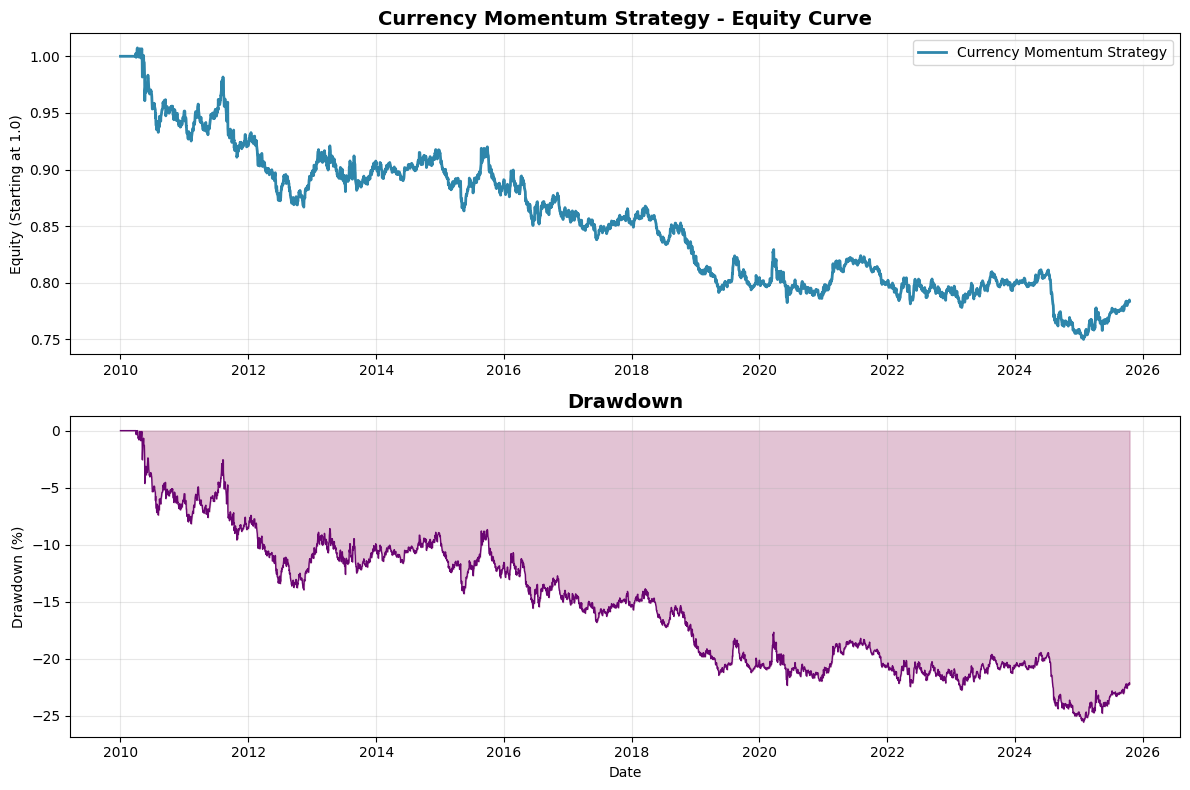

In [9]:
# Plot equity curve and drawdown
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Equity curve
ax1.plot(equity_curve.index, equity_curve.values, label='Currency Momentum Strategy', linewidth=2, color='#2E86AB')
ax1.set_title('Currency Momentum Strategy - Equity Curve', fontsize=14, fontweight='bold')
ax1.set_ylabel('Equity (Starting at 1.0)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Drawdown
ax2.fill_between(drawdown.index, drawdown.values * 100, 0, alpha=0.3, color='#A23B72')
ax2.plot(drawdown.index, drawdown.values * 100, color='#6A0572', linewidth=1)
ax2.set_title('Drawdown', fontsize=14, fontweight='bold')
ax2.set_ylabel('Drawdown (%)')
ax2.set_xlabel('Date')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Current Portfolio Allocation

Display the current recommended positions based on latest momentum readings.


In [10]:
# Get current positions
current_signals = signals.iloc[-1]
current_momentum = fx_momentum.iloc[-1].dropna().sort_values(ascending=False)
latest_date = fx_prices.index[-1].strftime('%Y-%m-%d')

print(f"Portfolio Status as of {latest_date}")
print("=" * 60)

print("\nCurrency Momentum Rankings:")
for i, (currency, mom) in enumerate(current_momentum.items(), 1):
    signal = current_signals[currency]
    position = "LONG" if signal == 1 else ("SHORT" if signal == -1 else "NEUTRAL")
    print(f"{i}. {currency}: {mom:+.2%} momentum - {position}")

print("\nActive Positions:")
long_positions = current_signals[current_signals == 1].index.tolist()
short_positions = current_signals[current_signals == -1].index.tolist()

if long_positions:
    print(f"Long: {', '.join(long_positions)}")
if short_positions:
    print(f"Short: {', '.join(short_positions)}")

print("\nSuggested Pairs:")
if long_positions and short_positions:
    for long_ccy in long_positions:
        for short_ccy in short_positions:
            print(f"  Long {long_ccy}/{short_ccy}")


Portfolio Status as of 2025-10-17

Currency Momentum Rankings:
1. CHF: +0.24% momentum - NEUTRAL
2. GBP: -0.48% momentum - NEUTRAL
3. EUR: -0.86% momentum - LONG
4. AUD: -1.74% momentum - LONG
5. JPY: -2.38% momentum - NEUTRAL
6. CAD: -2.89% momentum - SHORT
7. NZD: -5.14% momentum - SHORT

Active Positions:
Long: AUD, EUR
Short: CAD, NZD

Suggested Pairs:
  Long AUD/CAD
  Long AUD/NZD
  Long EUR/CAD
  Long EUR/NZD


## Performance Statistics


In [11]:
# Calculate comprehensive statistics
total_return = (1 + strategy_returns).prod() - 1
years = len(strategy_returns) / 252
cagr = (1 + total_return) ** (1 / years) - 1

sharpe = (strategy_returns.mean() / strategy_returns.std()) * np.sqrt(252) if strategy_returns.std() > 0 else 0

# Downside deviation (for Sortino ratio)
downside_returns = strategy_returns[strategy_returns < 0]
downside_std = downside_returns.std()
sortino = (strategy_returns.mean() / downside_std) * np.sqrt(252) if downside_std > 0 else 0

# Win rate
win_rate = len(strategy_returns[strategy_returns > 0]) / len(strategy_returns[strategy_returns != 0]) if len(strategy_returns[strategy_returns != 0]) > 0 else 0

stats = {
    'Total Return': f"{total_return:.2%}",
    'CAGR': f"{cagr:.2%}",
    'Annual Volatility': f"{strategy_returns.std() * np.sqrt(252):.2%}",
    'Sharpe Ratio': f"{sharpe:.2f}",
    'Sortino Ratio': f"{sortino:.2f}",
    'Max Drawdown': f"{max_drawdown:.2%}",
    'Win Rate': f"{win_rate:.2%}",
    'Best Day': f"{strategy_returns.max():.2%}",
    'Worst Day': f"{strategy_returns.min():.2%}"
}

print("\nStrategy Performance Summary")
print("=" * 60)
for key, value in stats.items():
    print(f"{key:.<40} {value:>15}")



Strategy Performance Summary
Total Return............................         -21.61%
CAGR....................................          -1.48%
Annual Volatility.......................           4.09%
Sharpe Ratio............................           -0.34
Sortino Ratio...........................           -0.48
Max Drawdown............................         -25.55%
Win Rate................................          49.73%
Best Day................................           1.61%
Worst Day...............................          -2.42%


## Export Results


In [12]:
# Create results dataframe
results = pd.DataFrame({
    'equity_curve': equity_curve,
    'daily_return': strategy_returns,
    'drawdown': drawdown * 100
})

# Add current positions
for currency in fx_prices.columns:
    results[f'signal_{currency}'] = signals[currency]

# Save to CSV
output_path = 'fx_momentum_results.csv'
results.to_csv(output_path)
print(f"Results saved to {output_path}")

# Display sample
print("\nSample of results:")
print(results.tail(10))


Results saved to fx_momentum_results.csv

Sample of results:
            equity_curve  daily_return  drawdown  signal_AUD  signal_CAD  \
Date                                                                       
2025-10-06        0.7827        0.0036  -22.3081           1          -1   
2025-10-07        0.7836        0.0011  -22.2189           1          -1   
2025-10-08        0.7831       -0.0006  -22.2635           1          -1   
2025-10-09        0.7834        0.0003  -22.2393           1          -1   
2025-10-10        0.7835        0.0002  -22.2255           1          -1   
2025-10-13        0.7828       -0.0008  -22.2913           1          -1   
2025-10-14        0.7835        0.0009  -22.2238           1          -1   
2025-10-15        0.7837        0.0002  -22.2081           1          -1   
2025-10-16        0.7849        0.0016  -22.0867           1          -1   
2025-10-17        0.7839       -0.0013  -22.1859           1          -1   

            signal_CHF  si